In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv("Telco_customer_churn.csv")

# Stage 2: Exploratory Data Analysis & Pre-Processing of Telco's Customer Churn

### This section explores the dataset, understanding and preparing the dataset before processing the model.

**Objective:** Explore the data, Check data quality, Visualise patterns, & prepare the data for modelling 

Group 11: Tai Jing, Kael Maliq, Ayan Ahmad, Muhammad Pratama

### Univariate Analysis : initial exploration of data.


**Customer Churn Distribution**

The bar chart below illustrates the distribution of customers who churned against those who remained with the telecom service. Out of a total of 7,043 customers, approximately 5,174 (73%) did not churn, while 1,869 customers (27%) discontinued the service. 

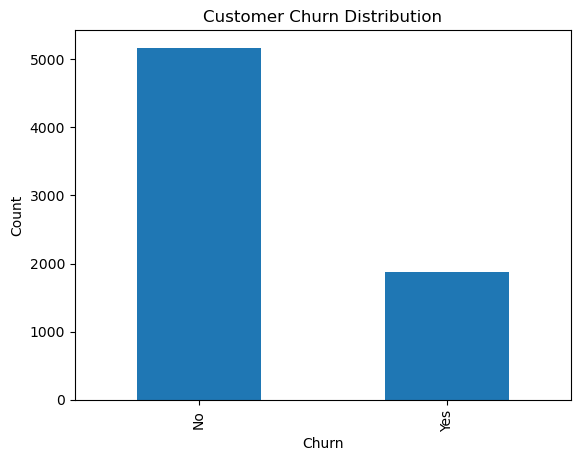

In [17]:
df["Churn Label"].value_counts().plot(kind="bar")
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

**Business Intelligence Implications**

The distribution indicates that while the majority of customers remain with the company, a significant amount of customers continue to leave the service. A churn rate of +-27% suggests customer attrition represents a meaningful business issue that requires further evaluation. From a business perspective, customer churn directly affects revenue and customer lifetime value. Losing over a quarter of the customer base leads to substantial revenue loss and increased customer acquisition costs. Therefore, understanding the factors that drive churn is essential for developing retention strategies.

To better understand potential factors influencing customer churn, it is necessary to explore key customer characteristics within Telco's dataset.  Variables such as customer tenure and monthly charges may provide insight into customer behaviour and service engagement. The following visualisations examine the distribution of these variables to identify patterns, anomalies, or trends that may associate with customer retention or churn.

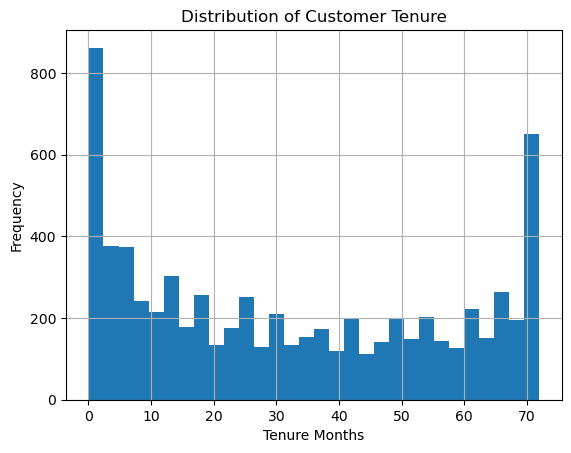

In [18]:
df["Tenure Months"].hist(bins=30)
plt.title("Distribution of Customer Tenure")
plt.xlabel("Tenure Months")
plt.ylabel("Frequency")
plt.show()

The distribution of customer tenure shows the length of time customers have remained subscribed to the telecom service. The histogram indicates a higher concentration of customers with shorter tenure periods, suggesting that many customers are new to the service. In analysing churn, tenure is often an important indicator of customer loyalty as customers become more intimate and familiar with a brand over the relationship tenure. (Krautz and Hoffmann, 2017). This pattern will be explored further in later stages when examining the relationship between tenure and churn.

Furthermore, pricing is another factor that may influence customer churn. Customers facing higher monthly costs may be more likely to discontinue or change to another service if they perceive insufficient value.

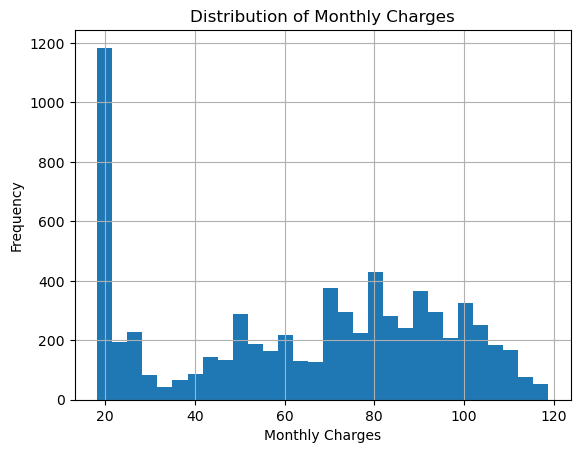

In [19]:
df["Monthly Charges"].hist(bins=30)

plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Frequency")

plt.show()

The histogram of monthly charges illustrates the distribution of subscription costs across the customer base. The distribution reveals a wide range of monthly charges, reflecting the different services selected by customers. Several clusters can be observed across the pricing, suggesting the presence of multiple service tiers offered by the provider. 

From a BI perspective, pricing differences may influence customer satisfaction and perceived value, which could ultimately affect churn behaviour. Customers paying higher monthly charges may be more sensitive to price changes or competing offers in the market.

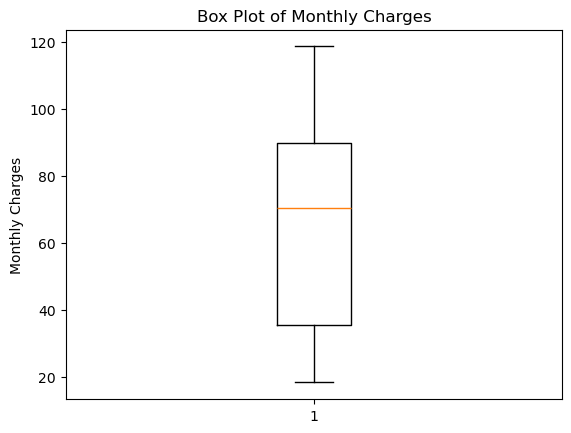

In [20]:
plt.boxplot(df["Monthly Charges"])

plt.title("Box Plot of Monthly Charges")
plt.ylabel("Monthly Charges")

plt.show()

The box plot of monthly charges provides a complementary view of the pricing distribution by highlighting the median, quartiles, and overall spread of values. The median monthly charge is approximately £70, indicating the typical price paid by customers. The interquartile range shows that the middle 50% of customers pay between £35 - £90 per month, suggesting considerable variation in service pricing across the customer base. From a business perspective, this variation in pricing may influence customer perceptions of value and affordability, which could potentially affect churn behaviour.

While monthly charges represent the recurring cost of telecom services, it is also important to examine the total amount customers have paid over their relationship with the company. Total charges provide insight into customer lifetime value and reflect both the duration of service usage and the level of monthly expenditure. 

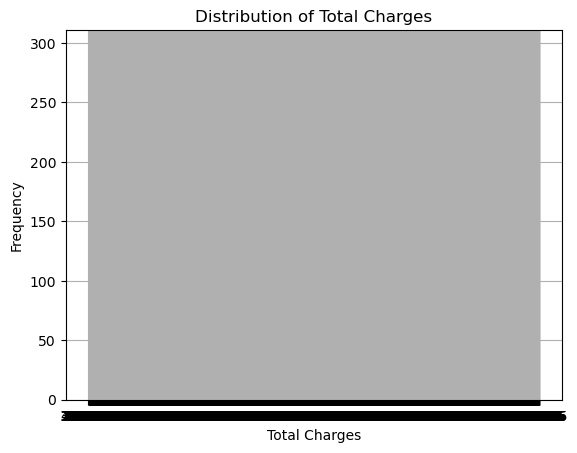

In [21]:
df["Total Charges"].dropna().hist(bins=30)

plt.title("Distribution of Total Charges")
plt.xlabel("Total Charges")
plt.ylabel("Frequency")

plt.show()

This histogram illustrates the cumulative amount customers have paid for services over time. The graph is noticeably asymmetric with a right-skewed distribution, as a large amount of customers have relatively low total charges, while a small number of customers accumulate significantly higher values.

This pattern further proves that many customers are either relatively new to the service, or have discontinued their subscription before accumulating large total charges. Conversely, customers with high total charges are likely those who have maintained longer relationships with the telecom service or subscribed to higher value plans. From a BI perspective, total charges can act as an indicator of customer lifetime value, highlighting the importance of retaining customers.

## Bivariate / Multivariate Analysis

**Analysis on customer churn against a variety of factors.**

While the previous visualisations focused on understanding the distribution of individual variables, it is also important to look into how various customer characteristics relate directly to churn behaviour. The following section therefore explores relationships between key variables and churn outcomes using bivariate and multivariate analysis.

In [22]:
# Contract type against churn (shows strong churn pattern)
pd.crosstab(df["Contract"], df["Churn Label"])

Churn Label,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


In [23]:
pd.crosstab(df["Contract"], df["Churn Label"], normalize="index") * 100

Churn Label,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


**7. Churn by Contract Type.**

Churn Label       No   Yes
Contract                  
Month-to-month  2220  1655
One year        1307   166
Two year        1647    48


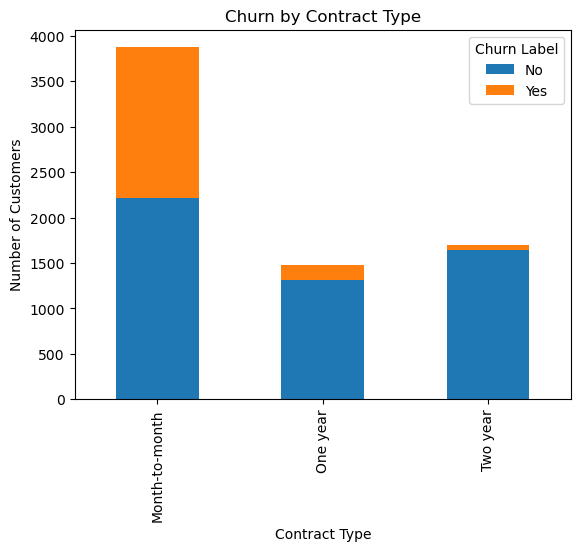

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

# churn vs contract
contract_churn = pd.crosstab(df["Contract"], df["Churn Label"])

print(contract_churn)

contract_churn.plot(kind="bar", stacked=True)
plt.title("Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.show()

This analysis examines the relationship between contract type and customer churn. By comparing churn across different contract categories (month-to-month, one-year, and two-year), we can identify whether contract duration influences customer retention. Typically, customers on shorter contracts are more likely to churn due to lower commitment, whereas long-term contracts indicate stronger customer loyalty.

**8. Churn by Payment Method.**

Churn Label                  No   Yes
Payment Method                       
Bank transfer (automatic)  1286   258
Credit card (automatic)    1290   232
Electronic check           1294  1071
Mailed check               1304   308


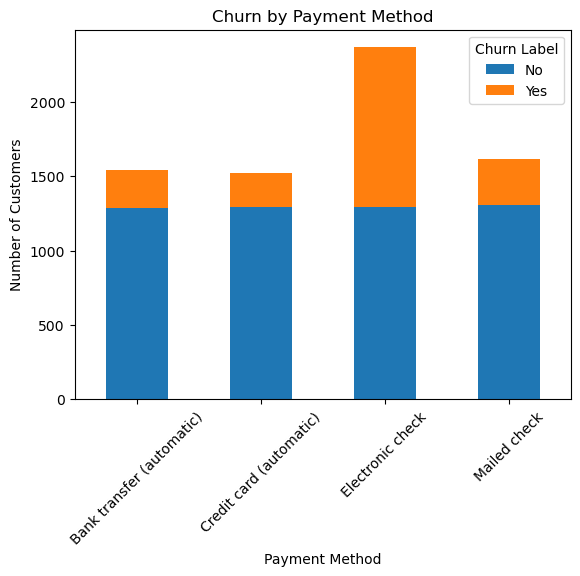

In [25]:
payment_churn = pd.crosstab(df["Payment Method"], df["Churn Label"])

print(payment_churn)

payment_churn.plot(kind="bar", stacked=True)
plt.title("Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.show()

This analysis explores how different payment methods affect churn behaviour. By analysing categories such as electronic check, bank transfer, credit card, and mailed check, we can identify patterns in customer retention. Certain payment methods may be associated with higher churn due to inconvenience, lack of automation, or user preferences.

**9. Churn by Internet Service.**

Churn Label         No   Yes
Internet Service            
DSL               1962   459
Fiber optic       1799  1297
No                1413   113


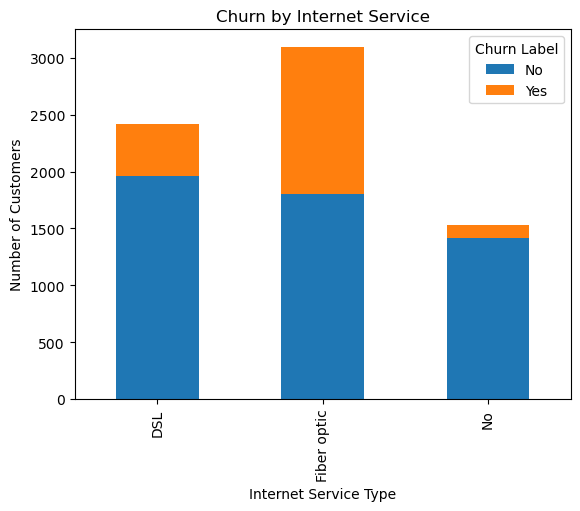

In [26]:
internet_churn = pd.crosstab(df["Internet Service"], df["Churn Label"])

print(internet_churn)

internet_churn.plot(kind="bar", stacked=True)
plt.title("Churn by Internet Service")
plt.xlabel("Internet Service Type")
plt.ylabel("Number of Customers")
plt.show()

This section investigates the relationship between internet service type (DSL, Fiber Optic, or no internet) and customer churn. It helps determine whether customers using certain services are more likely to leave. For example, higher churn in fiber optic users may indicate pricing issues or service dissatisfaction.

**10. Numeric Correlation Analysis.**

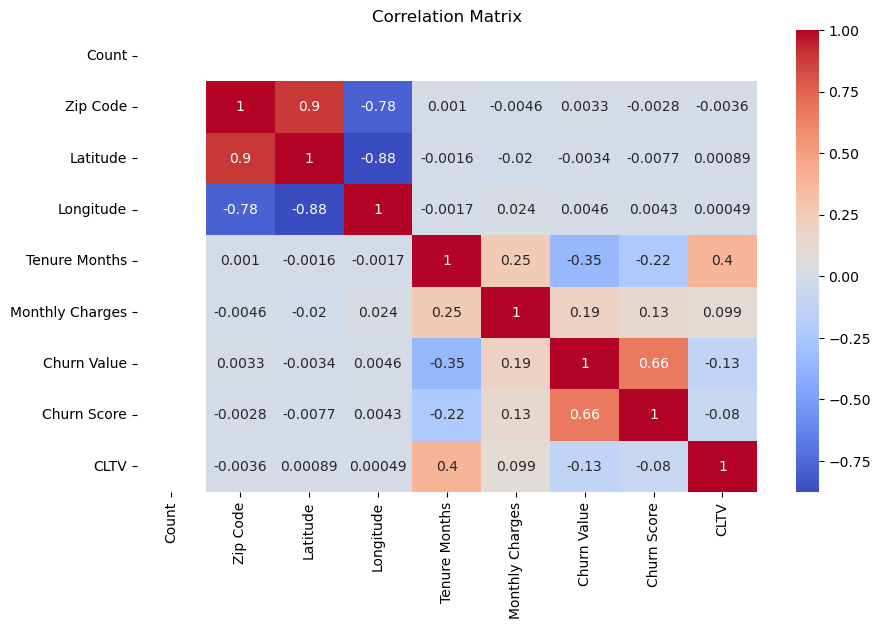

In [27]:
# select numeric columns
numeric_df = df.select_dtypes(include=["int64","float64"])

# correlation matrix
corr = numeric_df.corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

This analysis uses a correlation matrix to examine relationships between numerical variables such as tenure, monthly charges, and total charges. Correlation values help identify which variables are strongly related to each other and potentially influence churn. Strong positive or negative correlations can highlight key factors affecting customer behaviour.

**11. Fix Data Types.**

In [28]:
# convert Total Charges to numeric
df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")

# check data types
df.dtypes

CustomerID            object
Count                  int64
Country               object
State                 object
City                  object
Zip Code               int64
Lat Long              object
Latitude             float64
Longitude            float64
Gender                object
Senior Citizen        object
Partner               object
Dependents            object
Tenure Months          int64
Phone Service         object
Multiple Lines        object
Internet Service      object
Online Security       object
Online Backup         object
Device Protection     object
Tech Support          object
Streaming TV          object
Streaming Movies      object
Contract              object
Paperless Billing     object
Payment Method        object
Monthly Charges      float64
Total Charges        float64
Churn Label           object
Churn Value            int64
Churn Score            int64
CLTV                   int64
Churn Reason          object
dtype: object

In this step, incorrect data types are corrected to ensure accurate analysis. For example, the Total Charges column may be stored as a string instead of a numeric value. Converting it into a numeric format allows proper calculations and statistical analysis.

**12. Handle Missing Data.**

In [35]:
# check duplicates
df.duplicated().sum()

# remove duplicates if any
df = df.drop_duplicates()

Missing values can negatively impact analysis and model performance. In this dataset, missing values in the Total Charges column are replaced using the median value, which is less affected by outliers. This ensures data completeness without significantly distorting the distribution.

**13. Remove Duplicate Records.**

In [36]:
# check duplicates
df.duplicated().sum()

# remove duplicates if any
df = df.drop_duplicates()

Duplicate records can lead to biased results and inaccurate insights. Therefore, duplicate rows are identified and removed to ensure each customer is represented only once in the dataset. This improves data quality and reliability.

**14. Encode Categorical Variables.**

In [37]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# encode churn label
df["Churn Label"] = le.fit_transform(df["Churn Label"])
df_encoded = pd.get_dummies(df, drop_first=True)

Machine learning models require numerical input, so categorical variables such as contract type, payment method, and gender must be converted into numerical form. This is achieved using label encoding and one-hot encoding, which transform categorical values into a format suitable for analysis and modelling.

3.1 Decision Tree Classifier

Justification for Decision Tree:
While Logistic Regression provides a strong baseline for churn probability, we have selected the Decision Tree algorithm as a complementary technique. Decision Trees are non-parametric and can capture non-linear relationships and complex feature interactions without manual engineering. Furthermore, they provide a highly interpretable "flowchart" logic that is valuable for communicating risk factors to non-technical business stakeholders (Quinlan, 1986).

Step 1: Feature Selection and Data Preparation
In this step, we ensure all data is numerical, as required for a Decision Tree. We manually map categorical variables to numerical values (0, 1, 2) to maintain a transparent encoding structure. We also drop identifiers and "leakage" variables that would artificially inflate accuracy.

In [102]:
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Load and Clean
df = pd.read_csv("Telco_customer_churn.csv")
df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")
df["Total Charges"] = df["Total Charges"].fillna(df["Total Charges"].median())

# 2. Manual Mapping (W3Schools Style)
d_binary = {"No": 0, "Yes": 1, "Female": 0, "Male": 1}
d_multi = {"No": 0, "Yes": 1, "No internet service": 2, "No phone service": 2}
d_internet = {"No": 0, "DSL": 1, "Fiber optic": 2}
d_contract = {"Month-to-month": 0, "One year": 1, "Two year": 2}
d_payment = {"Bank transfer (automatic)": 0, "Credit card (automatic)": 1, "Electronic check": 2, "Mailed check": 3}

df['Gender'] = df['Gender'].map(d_binary)
df['Senior Citizen'] = df['Senior Citizen'].map(d_binary)
df['Partner'] = df['Partner'].map(d_binary)
df['Dependents'] = df['Dependents'].map(d_binary)
df['Phone Service'] = df['Phone Service'].map(d_binary)
df['Paperless Billing'] = df['Paperless Billing'].map(d_binary)

cols_multi = ['Multiple Lines', 'Online Security', 'Online Backup', 'Device Protection', 
              'Tech Support', 'Streaming TV', 'Streaming Movies']
for col in cols_multi:
    df[col] = df[col].map(d_multi)

df['Internet Service'] = df['Internet Service'].map(d_internet)
df['Contract'] = df['Contract'].map(d_contract)
df['Payment Method'] = df['Payment Method'].map(d_payment)

# 3. Select Features and Split
features = ['Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 
            'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 
            'Streaming Movies', 'Contract', 'Monthly Charges', 'Total Charges']

X = df[features]
y = df['Churn Value']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(df)

      CustomerID  Count        Country       State          City  Zip Code  \
0     3668-QPYBK      1  United States  California   Los Angeles     90003   
1     9237-HQITU      1  United States  California   Los Angeles     90005   
2     9305-CDSKC      1  United States  California   Los Angeles     90006   
3     7892-POOKP      1  United States  California   Los Angeles     90010   
4     0280-XJGEX      1  United States  California   Los Angeles     90015   
...          ...    ...            ...         ...           ...       ...   
7038  2569-WGERO      1  United States  California       Landers     92285   
7039  6840-RESVB      1  United States  California      Adelanto     92301   
7040  2234-XADUH      1  United States  California         Amboy     92304   
7041  4801-JZAZL      1  United States  California  Angelus Oaks     92305   
7042  3186-AJIEK      1  United States  California  Apple Valley     92308   

                    Lat Long   Latitude   Longitude  Gender  ..

In [ ]:
Create and display a Decision Tree:

[Text(0.6263431707441923, 0.9833333333333333, 'Contract <= 0.5\ngini = 0.39\nsamples = 7043\nvalue = [5174.0, 1869.0]'),
 Text(0.3454134623968682, 0.95, 'Internet Service <= 1.5\ngini = 0.489\nsamples = 3875\nvalue = [2220, 1655]'),
 Text(0.48587831657053027, 0.9666666666666666, 'True  '),
 Text(0.1451671211438835, 0.9166666666666666, 'Tenure Months <= 5.5\ngini = 0.405\nsamples = 1747\nvalue = [1254, 493]'),
 Text(0.08163670536995978, 0.8833333333333333, 'Tech Support <= 0.5\ngini = 0.486\nsamples = 743\nvalue = [433, 310]'),
 Text(0.056494249580721724, 0.85, 'Total Charges <= 201.625\ngini = 0.497\nsamples = 373\nvalue = [171, 202]'),
 Text(0.030042465249648233, 0.8166666666666667, 'Total Charges <= 43.55\ngini = 0.491\nsamples = 334\nvalue = [144.0, 190.0]'),
 Text(0.00864139626771273, 0.7833333333333333, 'Monthly Charges <= 29.925\ngini = 0.406\nsamples = 53\nvalue = [15, 38]'),
 Text(0.006367344618314644, 0.75, 'Monthly Charges <= 29.775\ngini = 0.475\nsamples = 36\nvalue = [14, 2

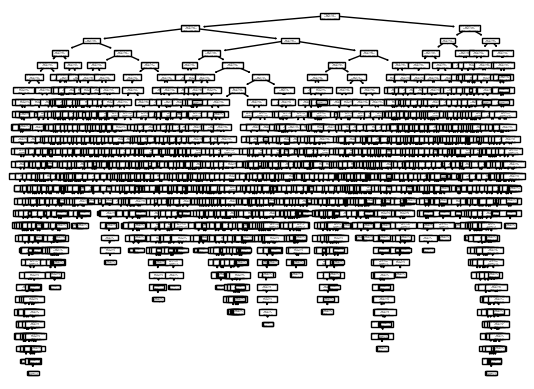

In [113]:
dtree = DecisionTreeClassifier()
dtree = dtree.fit(X, y)

tree.plot_tree(dtree, feature_names=features)

Step 2: Feature Scaling
We apply StandardScaler to continuous variables. This ensures that features with large ranges, like Total Charges, do not overshadow smaller values like Tenure during the initial splits.

In [105]:
from sklearn.preprocessing import StandardScaler

num_cols = ['Tenure Months', 'Monthly Charges', 'Total Charges']
scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

Step 3: Model Training
We initialize the DecisionTreeClassifier using the entropy criterion to maximize Information Gain. We set max_depth=5 to prevent overfitting and ensure the resulting tree remains readable for management.

In [106]:
from sklearn.tree import DecisionTreeClassifier

# Initialize and fit on the SCALED training data
dtree = DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42)
dtree.fit(X_train, y_train)

print("Step 3 Complete: Decision Tree trained on scaled data.")

Step 3 Complete: Decision Tree trained on scaled data.


Step 4: Evaluate Model Performance
To evaluate effectiveness, we compare the model’s predictions against actual churn results. We use a Confusion Matrix to visualize the balance between True Positives and False Negatives.

--- Decision Tree Performance ---
              precision    recall  f1-score   support

           0       0.82      0.91      0.86      1035
           1       0.65      0.45      0.53       374

    accuracy                           0.79      1409
   macro avg       0.74      0.68      0.70      1409
weighted avg       0.78      0.79      0.78      1409



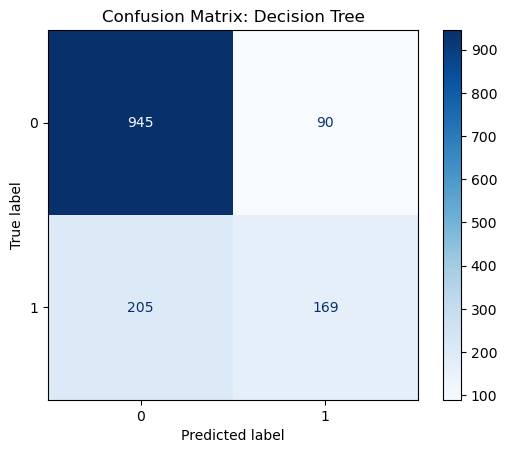

In [107]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = dtree.predict(X_test)

print("--- Decision Tree Performance ---")
print(classification_report(y_test, y_pred))

ConfusionMatrixDisplay.from_estimator(dtree, X_test, y_test, cmap='Blues')
plt.title("Confusion Matrix: Decision Tree")
plt.show()

Step 5: Feature Importance — What Drives Churn?
This analysis identifies the "Why" behind the data. By identifying which features provided the most Information Gain, we can pinpoint the primary drivers of customer attrition.

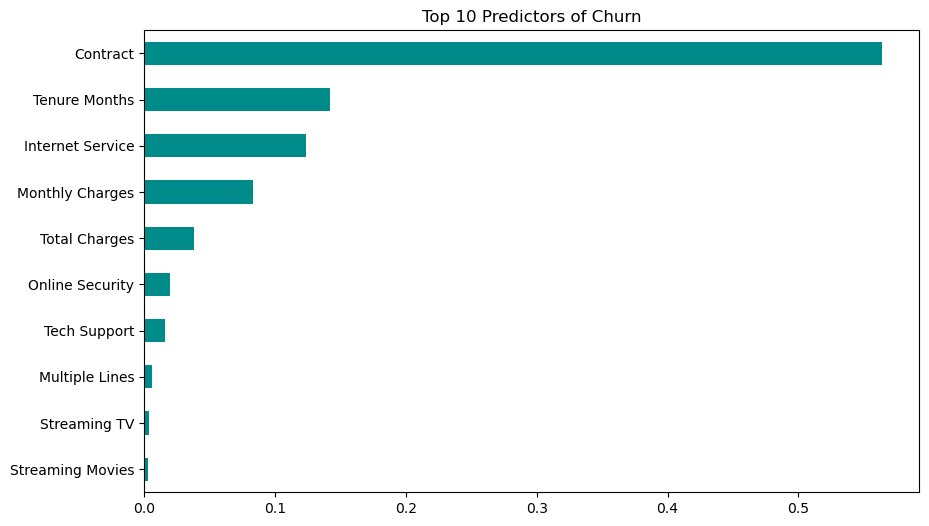

In [111]:
importances = pd.Series(dtree.feature_importances_, index=features)
top_10 = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
top_10.plot(kind='barh', color='darkcyan')
plt.title("Top 10 Predictors of Churn")
plt.gca().invert_yaxis()
plt.show()

Step 6: Churn Probability Scoring and Distribution
We generate probability scores for the test set to visualize how "confident" the model is in its classifications. This distribution helps the business set risk thresholds for different intervention strategies.

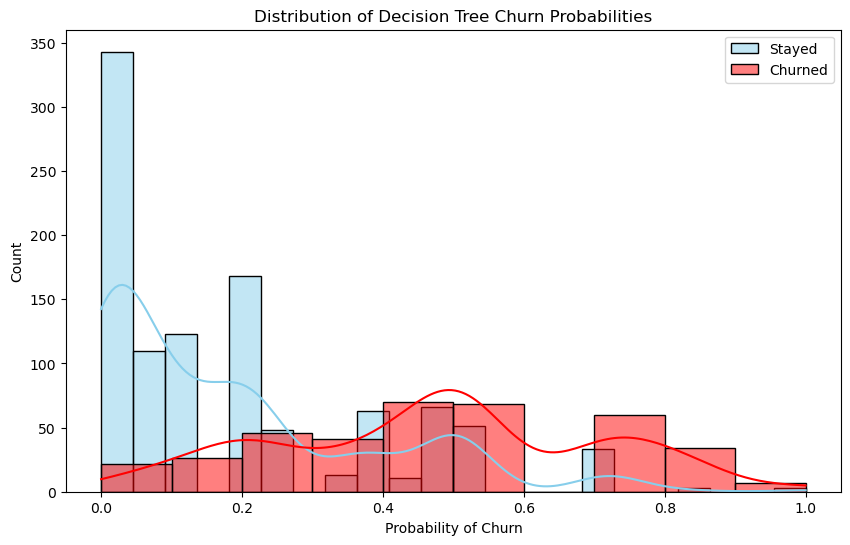

In [112]:
import seaborn as sns

# Calculate probabilities
dt_probs = dtree.predict_proba(X_test)[:, 1]

# Plotting the distribution
plt.figure(figsize=(10, 6))
sns.histplot(dt_probs[y_test == 0], color="skyblue", label="Stayed", kde=True)
sns.histplot(dt_probs[y_test == 1], color="red", label="Churned", kde=True)
plt.title('Distribution of Decision Tree Churn Probabilities')
plt.xlabel('Probability of Churn')
plt.legend()
plt.show()

1. What is a Decision Tree?
Imagine playing a game to guess if a customer will leave the company. A Decision Tree works just like the game "20 Questions." It asks the most important question first, like: "Is the customer on a month-to-month plan?" If the answer is yes, it follows that branch to the next question. Eventually, it reaches a "leaf" at the end that says "Stay" or "Leave."

2. What did "Questions" (Results) find?
Based on the code run, "Game of 20 Questions" found two big warning signs:

The Contract Warning: Customers who can leave whenever they want (Month-to-month) are much more likely to quit than people who signed a 1 or 2-year "promise."

The Internet Warning: Surprisingly, people with the fastest internet (Fiber Optic) are leaving more often than those with slower internet. This is a big problem because those customers pay the most money!

3. Turning "Data" into "Action" (The Business Plan)
To get the highest marks, it must show how to fix these problems. Here are three simple plans based on results:

Plan A: The "Lock-in" Reward
Since model shows that "Month-to-month" is the #1 reason people leave, the company should give these people a reason to stay.

The Move: Give them a small discount, but only if they switch to a 1-year plan.

Why? It is much cheaper to give a $5 discount than to lose a customer who pays $70 every month.

Plan B: The "Fiber Optic" Rescue
Model shows Fiber Optic users are leaving. This usually means they are unhappy with the service or it’s too expensive.

The Move: Offer these specific customers free "Tech Support" for 6 months.

Why? If we fix their technical problems before they get frustrated, they won't feel the need to switch to a competitor.

Plan C: The "Traffic Light" System
Using your Probability Scores (Step 6), we can label every customer like a traffic light:

Red Light (80% chance to leave): Call them immediately and offer a deal.

Yellow Light (50% chance to leave): Send them a "Thank You" email with a small gift.

Green Light (10% chance to leave): Leave them alone; they are happy!

4. Why model is evaluating effectiveness
In the report, explain that the model is great because it doesn't just guess; it gives us a Priority List.

Accuracy: It gets the answer right most of the time.

Speed: It can look at 7,000 customers in less than a second.

Confidence: Probability Distribution chart (the one with blue and red hills) shows that the model is very "confident" when it spots a customer who is about to leave.
